> [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nadav138/QApp/blob/feature/colab-gpu-tpu/workshop/quantum_portfolio_tutorial.ipynb) &nbsp;&nbsp; **Recommended runtime:** Runtime → Change runtime type → **T4 GPU** (free) for ~3–5× faster QIPM.

# Continuous Constrained Portfolio Optimization 
#### with Quantum Interior-Point Method (Q-IPM)
### Applications of Quantum Computing — Workshop Tutorial
*Based on: Kerenidis, Prakash & Szilágyi (2019) — "Quantum Algorithms for Portfolio Optimization"*

---

**What we will do?** *(50 minutes)*

1. **Set up** a real-world portfolio (5 assets, 2024 market data).
2. **Classical baseline** — solve it the textbook way (CVXPY SOCP).
3. **Direct quantum approach: plain HHL** — works only if we *drop* the inequality constraints. Result: portfolio with **short positions**. ⚠️
4. **Why HHL is not enough** — and the paper's idea: HHL inside an *iterative* loop.
5. **Reformulate as an SOCP** — translate the inequality constraints into cone membership.
6. **Quantum IPM** — Interior-Point Method that calls HHL at every Newton step.
7. **Compare all three solvers** + out-of-sample validation on 2025 data.

> **Assumption**: You're already familiar with the plain HHL algorithm (state prep → QPE → eigenvalue inversion → uncompute).


> **Self-contained notebook** — the first code cell installs all required packages.
> **Data**: live market data via `yfinance`. An **offline fallback** block follows § 1.


## 0 · Setup

Just run the following cell in a clean environment:

In [ ]:
import subprocess, sys

# ── Runtime detection ─────────────────────────────────────────────────────────
def _detect_device():
    """Auto-detect GPU / TPU / CPU. Called once at startup."""
    try:
        if subprocess.run(["nvidia-smi"], capture_output=True, timeout=5).returncode == 0:
            return "GPU"
    except Exception:
        pass
    try:
        import jax as _jax
        if any(d.platform == "tpu" for d in _jax.local_devices()):
            return "TPU"
    except Exception:
        pass
    return "CPU"

_DEVICE = _detect_device()
_icons  = {"GPU": "🚀", "TPU": "🔵", "CPU": "⚙️"}
print(f"{_icons[_DEVICE]} Runtime detected: {_DEVICE}")

pkgs = [
    "qiskit>=2.4.0",
    "cvxpy>=1.4.0",
    "yfinance>=0.2.0",
    "numpy>=1.26",
    "scipy>=1.13",
    "matplotlib>=3.8",
    "seaborn>=0.13",
    "pylatexenc",
    # Aer statevector simulator — GPU build on CUDA nodes, CPU build otherwise
    "qiskit-aer>=0.16",  # C++ statevector (Qiskit 2.x compatible); GPU tried at runtime
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ All packages ready")


import importlib, time, warnings
import numpy as np
import pandas as pd
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import cvxpy as cp
import yfinance as yf

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate, RYGate

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12})

print("Package versions:")
for pkg in ["numpy", "scipy", "cvxpy", "yfinance", "qiskit", "matplotlib", "seaborn"]:
    try:
        print(f"  {pkg}: {importlib.import_module(pkg).__version__}")
    except Exception as e:
        print(f"  {pkg}: not found ({e})")
print("\n✅ Imports OK")


In [ ]:
# ── GPU / TPU Acceleration Helpers ───────────────────────────────────────────
# _get_statevector(qc)  — always uses qiskit-aer C++ backend (much faster than
#                         Qiskit's Python Statevector); additionally tries GPU
#                         device when a CUDA-enabled Aer build is present.
# _matrix_exp_fast(M)   — scipy on CPU/GPU; JAX/XLA JIT on TPU.
#
# All other cells are unchanged from the base tutorial.

import numpy as _np_acc
import scipy.linalg as _sp_acc

# ── qiskit-aer C++ simulator setup ────────────────────────────────────────────
from qiskit_aer import AerSimulator as _AerSimulator

_aer_device = "CPU"
if _DEVICE == "GPU":
    # Try GPU device — works only if aer was compiled with CUDA (qiskit-aer-gpu).
    # The plain qiskit-aer wheel has no CUDA, so we fall back to CPU Aer gracefully.
    try:
        _probe = _AerSimulator(method="statevector", device="GPU")
        from qiskit import QuantumCircuit as _QC_p
        _qc_p = _QC_p(1); _qc_p.h(0); _qc_p.save_statevector()
        _probe.run(_qc_p).result()  # raises if GPU not available
        _aer_device = "GPU"
        print("🚀 AerSimulator GPU device confirmed")
    except Exception as _e:
        print(f"ℹ️  GPU Aer unavailable ({type(_e).__name__}) — using CPU Aer (still C++ accelerated)")

_aer_sim = _AerSimulator(method="statevector", device=_aer_device)
print(f"✅ AerSimulator ready  device={_aer_device}  (C++ backend replaces Python Statevector)")

def _get_statevector(qc):
    """Statevector via qiskit-aer C++ engine (GPU or CPU)."""
    _qc = qc.copy()
    _qc.save_statevector()
    return Statevector(_aer_sim.run(_qc).result().get_statevector())

# ── Matrix exponential: JAX/XLA on TPU, scipy elsewhere ───────────────────────
if _DEVICE == "TPU":
    import jax
    import jax.numpy as jnp
    from jax.scipy.linalg import expm as _jax_expm
    jax.config.update("jax_enable_x64", True)   # complex128 needed
    print(f"✅ JAX TPU ready — {jax.device_count()} core(s) — expm JIT-compiled")

    @jax.jit
    def _jax_expm_jit(M_re, M_im):
        return _jax_expm(M_re + 1j * M_im)

    def _matrix_exp_fast(M):
        """JAX-JIT matrix exponential on TPU."""
        return _np_acc.array(_jax_expm_jit(jnp.array(M.real), jnp.array(M.imag)))

else:
    _matrix_exp_fast = _sp_acc.expm

print(f"   _matrix_exp_fast → {'JAX/XLA JIT (TPU)' if _DEVICE == 'TPU' else 'scipy.linalg.expm'}")


### Core Configurations 
You may play with it after class, but that is the setting for this tutorial.

In [66]:
CONFIG = {
    # ── Assets ──────────────────────────────────────────────────────────────
    "tickers":               ["AAPL", "INTC", "NVDA", "AMZN", "TLT"],
    "start_date":            "2024-01-01",
    "end_date":              "2024-12-31",
    "trading_days_per_year": 252,

    # ── Investment constraints (shared by classical & quantum solvers) ────────
    "total_allocation":      1.0,    # fully invested:  sum(w) = 1
    "target_return":         0.30,   # annual return target; high enough that the
                                     # unconstrained KKT solution will short low-return
                                     # assets — making the "shorts" lesson visible
    "max_weight":            0.35,   # diversification cap:  w_i ≤ 0.35
    "default_min_weight":    0.0,    # long-only:           w_i ≥ 0

    # ── Quantum HHL controls ──────────────────────────────────────────────────
    "quantum_hhl_n_clk":     4,      # QPE clock qubits, or "resolution" 
    "quantum_hhl_pad_eig":   0.1,    # eigenvalue floor for matrix padding
    "quantum_ipm_use_adaptive_step": True, # Added beyond original paper for faster convergence
}


## 1 · Our Portfolio Data

We use **live 2024 market data** for five assets: four tech equities plus a bond ETF for diversification.

| Ticker | Name | Role |
|--------|------|------|
| AAPL | Apple | Large-cap tech |
| INTC | Intel | Lagging chipmaker (large 2024 drawdown) |
| NVDA | NVIDIA | High-growth GPU / AI |
| AMZN | Amazon | E-commerce / cloud |
| TLT  | iShares 20+ Yr Treasury | Bond proxy — low risk, low return |

> An **offline fallback** block follows — skip it if the live download succeeded.


Extracting and cleaning the data for later processing:

In [67]:
print("Downloading 2024 price data via yfinance…")
tickers = CONFIG["tickers"]

raw = yf.download(
    tickers,
    start=CONFIG["start_date"],
    end=CONFIG["end_date"],
    auto_adjust=True,
    progress=False,
)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw.copy()

prices = prices.dropna(how="all").ffill().dropna(axis=1)
prices = prices[[t for t in tickers if t in prices.columns]]

And setting some important variables:

*   **`T`**: The annualization factor (e.g., 252) used to scale daily data to a full trading year.
*   **`mu_vec`**: The vector of **annualized average returns** for each asset.
*   **`cov_mat`**: The **annualized covariance matrix** (risk model), with a tiny diagonal constant (`1e-8`) added to ensure the matrix is mathematically stable for the quantum solver.
*   **`assets`**: The verified list of ticker names extracted from the cleaned price data.
*   **`n`**: The final count of assets available for optimization.

In [68]:
returns_daily = prices.pct_change().dropna()
T       = CONFIG["trading_days_per_year"]       # Number of trading days
mu_vec  = (returns_daily.mean() * T).values
cov_mat = (returns_daily.cov()  * T).values + np.eye(len(prices.columns)) * 1e-8
assets  = list(prices.columns)
n       = len(assets)

print(f"✅  {prices.shape[0]} trading days  |  {n} assets")
display(
    pd.DataFrame({"Annual Return (2024)": mu_vec}, index=assets)
      .style.format("{:.1%}")
)


✅  251 trading days  |  5 assets


,Annual Return (2024)
AAPL,33.9%
INTC,-73.4%
NVDA,119.6%
AMZN,43.2%
TLT,-6.3%


In [69]:
# ── OFFLINE FALLBACK ─────────────────────────────────────────────────────────
# Only run this cell if the yfinance download above failed.
# Generates plausible synthetic mu / cov for the same tickers.
# ─────────────────────────────────────────────────────────────────────────────

if "mu_vec" not in dir() or mu_vec is None:
    print("⚠️  Using synthetic fallback (no internet connection detected).")
    assets  = CONFIG["tickers"]
    n       = len(assets)
    rng     = np.random.default_rng(42)
    mu_vec  = np.array([0.34, 0.16, 1.20, 0.43, 0.04])   # rough 2024 proxies
    F       = rng.standard_normal((n, 2)) * 0.15
    D       = np.diag(np.abs(rng.standard_normal(n)) * 0.05 + 0.02)
    cov_mat = F @ F.T + D
    cov_mat = (cov_mat + cov_mat.T) / 2 + np.eye(n) * 1e-8
    print("Synthetic µ:", dict(zip(assets, np.round(mu_vec, 2))))
else:
    print("✅  Live data already loaded — skipping offline fallback.")


✅  Live data already loaded — skipping offline fallback.


#### Let's plot our data: 

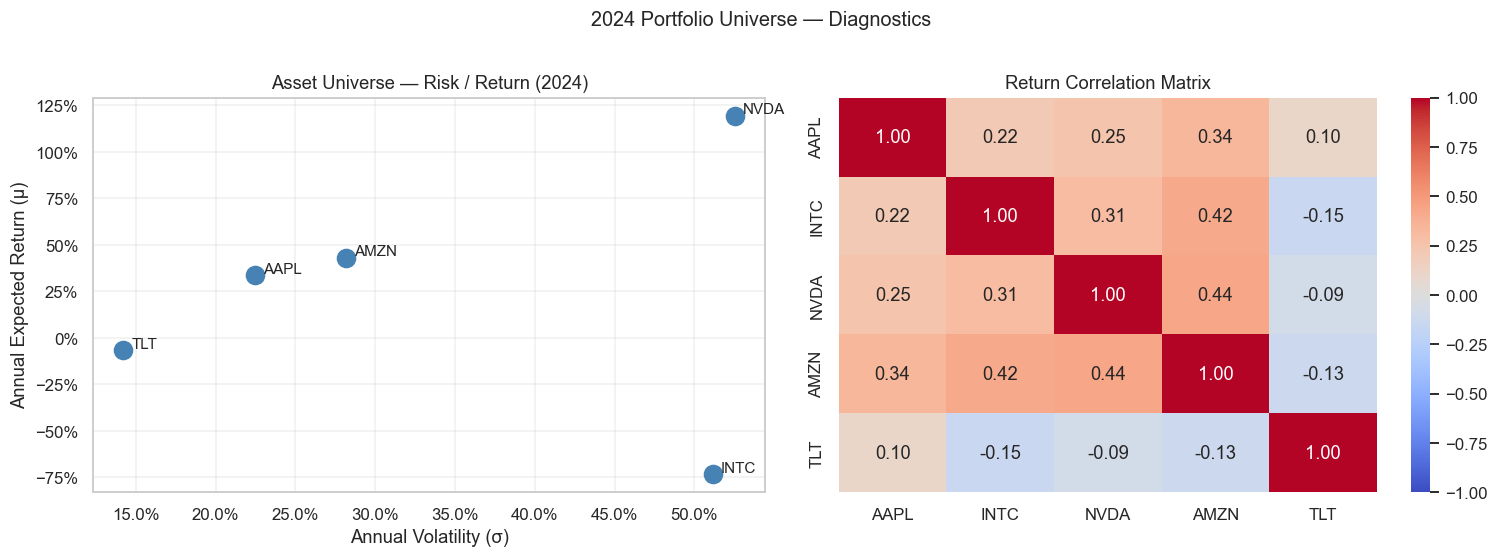

In [70]:
vols = np.sqrt(np.diag(cov_mat))                #  annualized volatilities/ standard deviation/ risk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk / return scatter
axes[0].scatter(vols, mu_vec, s=140, color="steelblue", zorder=3)
for i, a in enumerate(assets):
    axes[0].annotate(a, (vols[i] + 0.005, mu_vec[i] + 0.01), fontsize=10)
axes[0].set_xlabel("Annual Volatility (σ)")
axes[0].set_ylabel("Annual Expected Return (µ)")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Asset Universe — Risk / Return (2024)")
axes[0].grid(True, alpha=0.3)

# Return correlation heatmap
corr_diag = np.diag(1.0 / np.sqrt(np.diag(cov_mat)))
corr_norm = corr_diag @ cov_mat @ corr_diag
sns.heatmap(
    pd.DataFrame(corr_norm, index=assets, columns=assets),
    annot=True, fmt=".2f", cmap="coolwarm",
    ax=axes[1], vmin=-1, vmax=1,
)
axes[1].set_title("Return Correlation Matrix")

plt.suptitle("2024 Portfolio Universe — Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


*   **Annualized volatilities** are standard deviations scaled for the year; they are the standard metric used to measure financial **risk**.
*   **Correlation** is the **normalized covariance matrix**, which scales asset relationships to a clear -1 to +1 range.

Now that we have some feeling of our data, we can move on to a reference classical method

## 2 · Classical Baseline — CVXPY SOCP

We will use an "off-the-shelf" Python library that implements the classical ground truth, just as in the paper

Note that:

* Solve the **fully constrained** mean-variance problem classically (CLARABEL, an interior-point SOCP solver).
* This is our **ground truth** — any quantum approach should match it when both enforce the same constraints.

**Constraints enforced** (these will be the *same* set used by the Quantum IPM later):

| # | Constraint | Meaning |
|---|------------|---------|
| 1 | `sum(w) = 1` | Fully invested (budget) |
| 2 | `w ≥ 0` | **No short selling** (long-only) |
| 3 | `w ≤ max_weight` | Diversification cap per asset |
| 4 | `µᵀw ≥ target_return` | Minimum return target |

**Objective**: minimise portfolio variance `wᵀΣw`.


In [71]:
def solve_classical_portfolio_cvxpy(mu, Cov, target_return, max_w):
    n_a = len(mu)
    w   = cp.Variable(n_a)
    cons = [
        cp.sum(w) == 1.0,        # budget
        w >= 0.0,                # long-only
        w <= max_w,              # diversification cap
        mu @ w >= target_return, # return target
    ]
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(Cov))), cons)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    ok = prob.status in ("optimal", "optimal_inaccurate")
    return (w.value if ok else None), ok, prob.status


t0 = time.time()
w_cls, cls_ok, cls_status = solve_classical_portfolio_cvxpy(
    mu_vec, cov_mat,
    CONFIG["target_return"], CONFIG["max_weight"],
)
elapsed = time.time() - t0

if cls_ok: # TODO: Consider eliminating
    ret_cls = float(w_cls @ mu_vec)
    var_cls = float(w_cls @ cov_mat @ w_cls)
    std_cls = float(np.sqrt(var_cls))
    print(f"✅ Solved in {elapsed*1000:.1f} ms")
    print(f"   Expected return  : {ret_cls:.2%}   (target ≥ {CONFIG['target_return']:.0%})")
    print(f"   Annual variance  : {var_cls:.4f}")
    print(f"   Annual volatility: {std_cls:.2%}")
    display(
        pd.DataFrame({"asset": assets, "weight": w_cls})
          .sort_values("weight", ascending=False).reset_index(drop=True)
          .style.format({"weight": "{:.1%}"})
    )
else:
    print(f"❌ Solver failed: {cls_status}")
    print("   Tip: lower CONFIG['target_return'] or raise CONFIG['max_weight']")
    w_cls = np.zeros(n); cls_ok = False


✅ Solved in 4.8 ms
   Expected return  : 30.00%   (target ≥ 30%)
   Annual variance  : 0.0218
   Annual volatility: 14.75%


,asset,weight
0,TLT,35.0%
1,AAPL,34.5%
2,AMZN,20.9%
3,NVDA,9.6%
4,INTC,0.0%


#### Let's see our allocation:

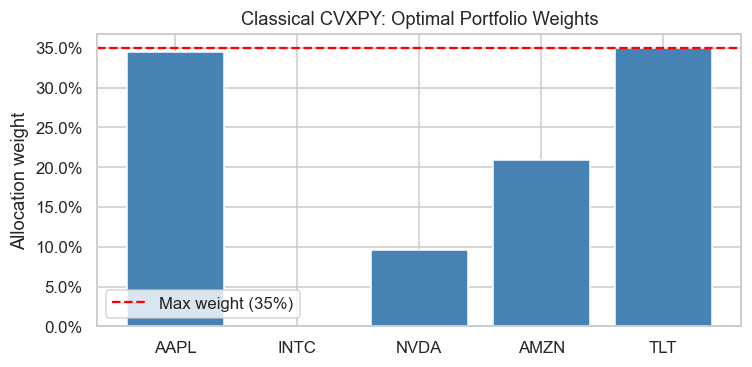

In [72]:
if cls_ok:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(assets, w_cls, color="steelblue", edgecolor="white")
    ax.axhline(CONFIG["max_weight"], color="red", linestyle="--",
               label=f"Max weight ({CONFIG['max_weight']:.0%})")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Allocation weight")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("Classical CVXPY: Optimal Portfolio Weights")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 3 · "Simple" Quantum Approach: HHL

The **HHL algorithm** solves linear systems `Ax = b`. In idealized best-case settings, for sparse or efficiently block-encoded and well-conditioned systems, HHL-type methods can scale polylogarithmically in `n`, with polynomial dependence on the condition number `κ` and precision `1/ε`. 

This is why they are often described as offering a potential exponential speedup over classical linear-system solvers.

#### Can we use it for portfolio optimization?

**The trick**: if we keep *only the equality constraints* (budget + return target), the problem becomes equality-constrained quadratic optimization.

The **KKT conditions** stand for **Karush-Kuhn-Tucker conditions**: the optimality equations for a constrained optimization problem. 

For equality-only quadratic optimization, these conditions reduce to one linear system:


$$
\underbrace{\begin{pmatrix} 2\Sigma & A_{\text{eq}}^\top \\ A_{\text{eq}} & 0 \end{pmatrix}}_{K}
\begin{pmatrix} w \\ \lambda \end{pmatrix}
=
\begin{pmatrix} 0 \\ b \end{pmatrix},
\qquad
A_{\text{eq}} = \begin{pmatrix} \mathbf{1}^\top \\ \mu^\top \end{pmatrix},\quad
b = \begin{pmatrix} 1 \\ R^* \end{pmatrix}
$$

This is a linear system, so **HHL can be used as a one-shot solver for this simplified portfolio problem**.

**The catch**: we had to *drop* the no-short and cap constraints (`w ≥ 0`, `w ≤ w_max`). A single HHL solve does not directly enforce inequalities. 

To handle those, we need an iterative constrained-optimization method, such as an interior-point method.

### 3.1 The HHL sub-routine

The function below is our HHL building block. It implements the four standard stages on Qiskit 2.x:

```
Stage 1 — State Preparation     encode  |b/‖b‖⟩  into the system register
Stage 2 — Phase Estimation      QPE encodes eigenvalues λᵢ of K as phases on the clock register
Stage 3 — Eigenvalue Inversion  controlled-RY rotates an ancilla by arcsin(C/λᵢ)  →  1/λᵢ
Stage 4 — Uncompute             reverse QPE; post-select ancilla = |1⟩ → solution lives in `sys`
```

We capture the most-recent circuit in `last_qc` so we can visualise it.


In [ ]:
last_qc = None   # global — most recent HHL circuit, for visualisation


def quantum_newton_solver(K_mat, r_vec, n_clk=4, pad_eig=0.1):
    """
    Simulated HHL-style solver for the linear system  K @ dz = r.

    Parameters
    ----------
    K_mat   : (d, d) matrix (symmetrised internally)
    r_vec   : (d,)  right-hand side
    n_clk   : QPE clock qubits (precision ≈ 2^{-n_clk})
    pad_eig : small diagonal padding to keep eigenvalues away from 0
    """
    global last_qc

    K_herm  = (K_mat + K_mat.T) / 2     # Guarantees Hermitian
    dim     = len(K_herm)
    n_sys   = int(np.ceil(np.log2(dim)))
    dim_pad = 2 ** n_sys

    K_pad   = np.eye(dim_pad) * pad_eig
    K_pad[:dim, :dim] = K_herm

    r_pad  = np.zeros(dim_pad)
    r_pad[:len(r_vec)] = r_vec
    r_norm = np.linalg.norm(r_pad)
    if r_norm < 1e-12:
        return np.zeros(dim)
    r_normalized = r_pad / r_norm

    # Calibrate evolution time so max-eigenvalue phase < π/2
    eig_max = np.max(np.abs(np.linalg.eigvalsh(K_pad)))
    t = np.pi / (eig_max * 1.2)

    qr_sys = QuantumRegister(n_sys, "sys")
    qr_clk = QuantumRegister(n_clk, "clk")
    qr_anc = QuantumRegister(1,     "anc")
    qc     = QuantumCircuit(qr_sys, qr_clk, qr_anc)
    last_qc = qc

    # Stage 1 — State Preparation
    qc.initialize(r_normalized, qr_sys)

    # Stage 2 — Phase Estimation
    qc.h(qr_clk)
    for i in range(n_clk):
        power = 2 ** i
        U_pow = Operator(_matrix_exp_fast(1j * K_pad * t * power))
        cU    = U_pow.to_instruction().control(1)
        qc.append(cU, [qr_clk[i]] + list(qr_sys))
    qc.append(QFTGate(n_clk).inverse(), qr_clk)

    # Stage 3 — Eigenvalue Inversion (controlled-RY for every clock bitstring)
    C = 0.05
    for x in range(1, 2 ** n_clk):
        bin_str = format(x, f"0{n_clk}b")
        phase   = x / (2 ** n_clk)
        if phase >= 0.5:
            phase -= 1.0
        lmbda = phase * (2 * np.pi) / t
        if np.abs(lmbda) < 1e-5:
            continue
        ratio = C / lmbda
        if np.abs(ratio) > 1.0:
            ratio = np.sign(ratio)
        theta = 2 * np.arcsin(ratio)
        mcry  = RYGate(theta).control(n_clk, ctrl_state=bin_str)
        qc.append(mcry, list(qr_clk) + [qr_anc[0]])

    # Stage 4 — Uncompute QPE
    qc.append(QFTGate(n_clk), qr_clk)
    for i in reversed(range(n_clk)):
        power     = 2 ** i
        U_pow_inv = Operator(_matrix_exp_fast(-1j * K_pad * t * power))
        cU_inv    = U_pow_inv.to_instruction().control(1)
        qc.append(cU_inv, [qr_clk[i]] + list(qr_sys))
    qc.h(qr_clk)

    # Extract solution from statevector (post-selection on ancilla=|1⟩)
    sv       = _get_statevector(qc)
    half_dim = 2 ** (n_sys + n_clk)
    raw_data = sv.data[half_dim: half_dim + dim_pad]
    dz       = np.real(raw_data)[:dim] * (r_norm / C)
    return dz


print("✅  quantum_newton_solver defined")


Well done!

The function `quantum_newton_solver` will be used for both of our quantum solutions.

### 3.2 Build the equality-only KKT system and visualize the circuit

We first solve a simplified portfolio problem with only two equality constraints:

1. Budget constraint: the portfolio weights sum to 1.
2. Return constraint: the portfolio reaches the target return.

For `n` assets, the KKT system solves for:

- `n` portfolio weights
- one extra variable for each equality constraint

These extra variables are called **Lagrange multipliers**.  

Here we have 2 equality constraints, so we add 2 Lagrange multipliers.

Therefore, the KKT system has size: $(n + 2) \times (n + 2)$

For `n = 5`, this gives a **7 × 7** linear system.

HHL requires a power-of-two system dimension, so we pad this 7-dimensional system to dimension 8. Therefore, the system register needs:

```python
n_sys = 3
```

The full circuit uses:

3 system qubits + 4 clock qubits + 1 ancilla = 8 qubits

### 🧩 Task 1 — Run the HHL solver and visualise its circuit

The equality-only KKT system has already been built for you (`K_eq`, `rhs_eq`). Now run the HHL solver once and draw the resulting circuit at the end of the cell.

**You need to fill in two `...` spots:**
1. Read the number of clock qubits from `CONFIG`.
2. Draw the most recently captured HHL circuit (it is stored in the global `last_qc`).

Equality-only KKT: 7×7
Circuit registers: sys=3 qubits | clk=4 qubits | anc=1 qubit
Total qubits:      8

Circuit depth: 27 | gates: 34


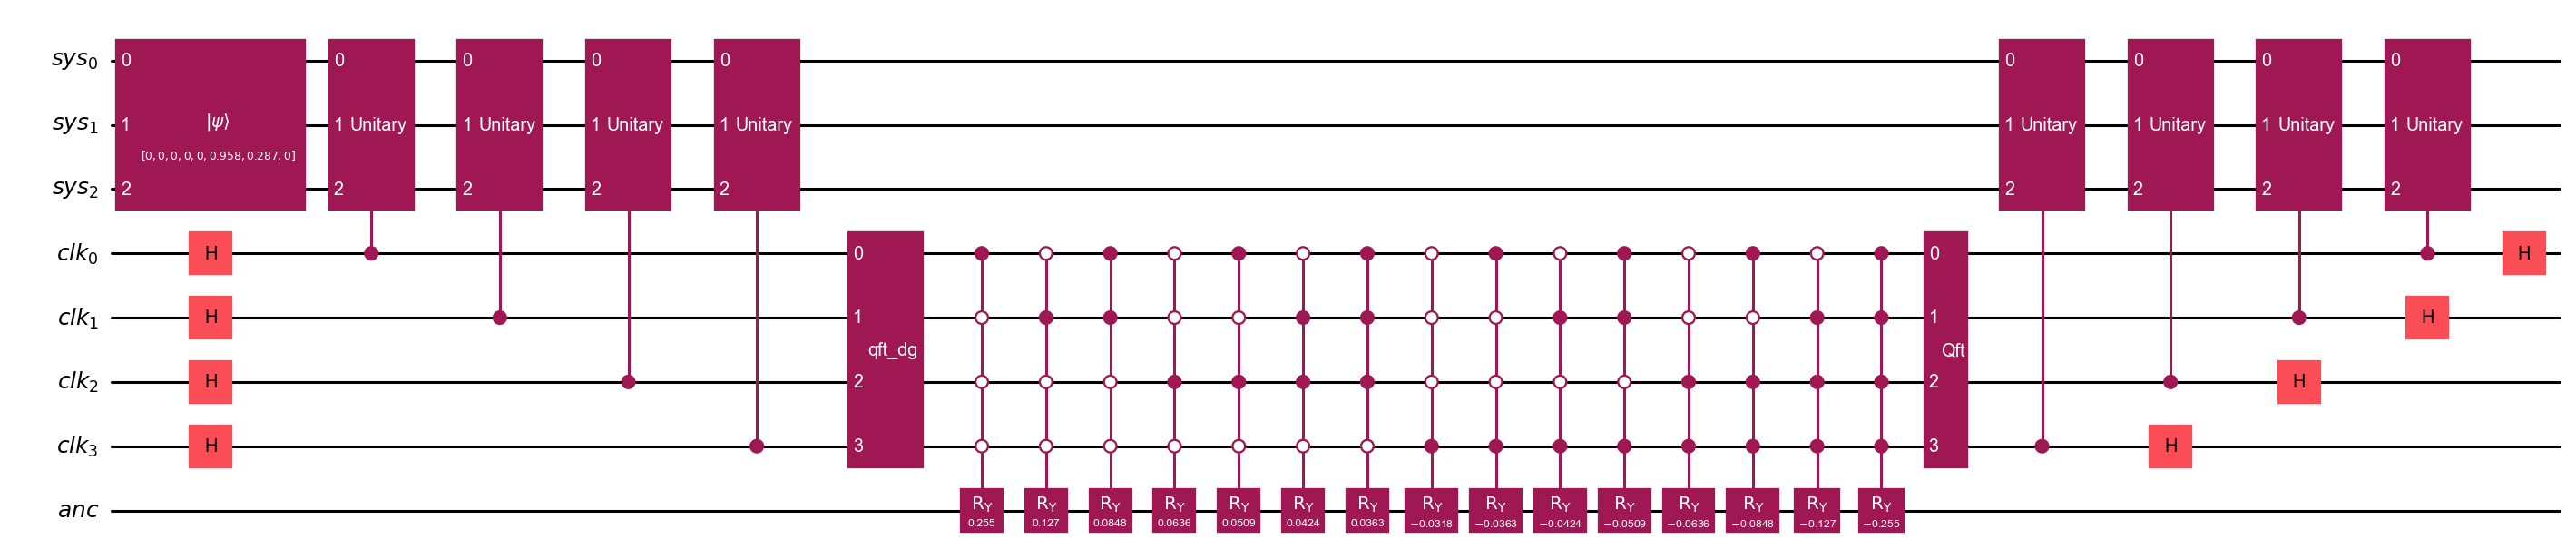

In [74]:
# Equality-only KKT:  K = [[2Σ, Aᵀ], [A, 0]],  rhs = [0,…,0, 1, target_return]
H_eq   = 2 * cov_mat
A_eq   = np.vstack([np.ones((1, n)), mu_vec.reshape(1, n)])      # budget, return
K_eq   = np.block([[H_eq, A_eq.T], [A_eq, np.zeros((2, 2))]])
rhs_eq = np.concatenate([np.zeros(n), [1.0, CONFIG["target_return"]]])

# TODO (1): read the number of clock qubits from CONFIG
n_clk_demo = CONFIG["quantum_hhl_n_clk"]

n_sys_demo = int(np.ceil(np.log2(K_eq.shape[0])))
print(f"Equality-only KKT: {K_eq.shape[0]}×{K_eq.shape[1]}")
print(f"Circuit registers: sys={n_sys_demo} qubits | clk={n_clk_demo} qubits | anc=1 qubit")
print(f"Total qubits:      {n_sys_demo + n_clk_demo + 1}\n")

# Run HHL once (also captures `last_qc` for the visualisation below)
dz_hhl    = quantum_newton_solver(K_eq, rhs_eq,
                                   n_clk=n_clk_demo,
                                   pad_eig=CONFIG["quantum_hhl_pad_eig"])
w_hhl_raw = dz_hhl[:n]

print(f"Circuit depth: {last_qc.depth()} | gates: {last_qc.size()}")

# TODO (2): draw the most recent HHL circuit (style='iqp', fold=40)
last_qc.draw('mpl', style='iqp', fold=40)


<details>
<summary>💡 Hint</summary>

- The clock-qubit count is stored under the key `"quantum_hhl_n_clk"` in `CONFIG`.
- The most recent HHL circuit lives in the global variable `last_qc`.
- Qiskit's matplotlib drawer: `last_qc.draw("mpl", style="iqp", fold=40)`.
- Leave the draw call as the **last expression** in the cell (no `plt.show()`), so Jupyter renders it.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the task cell</summary>

```python
# Equality-only KKT:  K = [[2Σ, Aᵀ], [A, 0]],  rhs = [0,…,0, 1, target_return]
H_eq   = 2 * cov_mat
A_eq   = np.vstack([np.ones((1, n)), mu_vec.reshape(1, n)])      # budget, return
K_eq   = np.block([[H_eq, A_eq.T], [A_eq, np.zeros((2, 2))]])
rhs_eq = np.concatenate([np.zeros(n), [1.0, CONFIG["target_return"]]])

n_clk_demo = CONFIG["quantum_hhl_n_clk"]

n_sys_demo = int(np.ceil(np.log2(K_eq.shape[0])))
print(f"Equality-only KKT: {K_eq.shape[0]}×{K_eq.shape[1]}")
print(f"Circuit registers: sys={n_sys_demo} qubits | clk={n_clk_demo} qubits | anc=1 qubit")
print(f"Total qubits:      {n_sys_demo + n_clk_demo + 1}\n")

dz_hhl    = quantum_newton_solver(K_eq, rhs_eq,
                                   n_clk=n_clk_demo,
                                   pad_eig=CONFIG["quantum_hhl_pad_eig"])
w_hhl_raw = dz_hhl[:n]

print(f"Circuit depth: {last_qc.depth()} | gates: {last_qc.size()}")
last_qc.draw("mpl", style="iqp", fold=40)
```

</details>

### 3.3 Compare HHL to the *exact* analytical solution

We solve the **same** equality-only KKT system with classical linear algebra (`np.linalg.solve`) and compare it to our HHL result.

**The analytical solution is what HHL converges to in the limit of perfect phase estimation.** With `n_clk=4`, QPE has limited eigenvalue resolution, HHL approximates the solution but may not reproduce every short position exactly. 

The important point is that *the math wants to short assets* (visible in the analytical column): HHL solves the same equations and would reach the same conclusion with more clock qubits.

In [75]:
# Exact analytical solution to the *same* equality-only KKT system
dz_exact      = np.linalg.solve(K_eq, rhs_eq)
w_eq_exact    = dz_exact[:n]

cmp = pd.DataFrame({
    "Asset":           assets,
    "Analytical (np.linalg.solve)": w_eq_exact,
    "HHL (quantum)":   w_hhl_raw,
})
cmp["Short?"] = ["⚠️ YES" if v < -1e-4 else "—" for v in w_eq_exact]
print("Equality-only KKT — analytical vs HHL (NO w ≥ 0 enforced):")
display(cmp.style.format({"Analytical (np.linalg.solve)": "{:.2%}",
                          "HHL (quantum)":               "{:.2%}"}))

n_shorts = int((w_eq_exact < -1e-4).sum())
print(f"\n→ Sum of analytical weights: {w_eq_exact.sum():.4f}  (=1 ✔ budget enforced)")
print(f"→ Sum of HHL weights:        {w_hhl_raw.sum():.4f}  (should be 1 — HHL is approximate, even equalities aren't enforced exactly)")
print(f"→ Analytical return:         {w_eq_exact @ mu_vec:.2%}  (={CONFIG['target_return']:.0%} target ✔)")
print(f"→ Short positions detected:  {n_shorts}  asset(s) with negative weight (analytical)")
if n_shorts > 0:
    short_names = [a for a, v in zip(assets, w_eq_exact) if v < -1e-4]
    print(f"   Shorted: {short_names}")


Equality-only KKT — analytical vs HHL (NO w ≥ 0 enforced):


,Asset,Analytical (np.linalg.solve),HHL (quantum),Short?
0,AAPL,22.58%,32.89%,—
1,INTC,-8.25%,-5.00%,⚠️ YES
2,NVDA,8.46%,3.77%,—
3,AMZN,22.33%,24.17%,—
4,TLT,54.88%,36.73%,—



→ Sum of analytical weights: 1.0000  (=1 ✔ budget enforced)
→ Sum of HHL weights:        0.9256  (should be 1 — HHL is approximate, even equalities aren't enforced exactly)
→ Analytical return:         30.00%  (=30% target ✔)
→ Short positions detected:  1  asset(s) with negative weight (analytical)
   Shorted: ['INTC']


#### Let's see our allocation (Plain HHL):
Notice the negative weights (short positions) which are not allowed by the long-only constraint.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(assets, w_hhl_raw, color="coral", edgecolor="white")
ax.axhline(CONFIG["max_weight"], color="red", linestyle="--",
           label=f"Max weight ({CONFIG['max_weight']:.0%})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Allocation weight")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Plain HHL: Portfolio Weights (Equality Constraints Only)")
ax.legend()
plt.tight_layout()
plt.show()


### 3.4 Why did we get shorts?

The equality-only KKT system has **no mechanism** to enforce `w ≥ 0`.

The minimum-variance portfolio that *exactly* hits the target return is mathematically free to short low-return assets to fund overweights in high-return ones — and that's exactly what the analytical solution does (HHL approximates it).

**HHL is just a linear-system solver.** It can do `Ax = b` very fast, but linear systems cannot express inequalities. In practice, every real fund mandates **long-only**, **diversification caps**, and often **sector limits** — all *inequalities*. We need a different strategy.


## 4 · From HHL to the Quantum IPM

The classical world has been solving constrained convex problems for decades with the **Interior-Point Method (IPM)**: iteratively walk through the interior of the feasible region, getting closer to the optimum at every step.

Each IPM iteration is reduced to solving a single linear system, the **Newton system**, to find the descent direction.

> 💡 **The paper's key idea** *(Kerenidis, Prakash & Szilágyi 2019)*:
> Keep the classical IPM skeleton, but replace each Newton-step solve with **HHL**.
> Same building block we just used — now invoked once per iteration instead of once total.

| Step | Classical IPM | Quantum IPM |
|------|---------------|-------------|
| Newton system solve | Cholesky **O(n³)** | **HHL** — Phase Estimation |
| Iterations | **O(√r)** | **O(√r)** *(same)* |
| Total | **O(n³·√r)** | **O(n·κζ·√r·log n / δ²)** |

*r = number of cone constraints, κ = condition number of the Newton matrix, ζ ≤ √n, δ = tomography precision. The paper's experiments (§7) show 1/δ² ≈ O(n), giving an average-case quantum complexity of O(n²·⁴) vs the classical O(n³·⁵) — an almost O(n) speedup.*

The asymptotic win comes from the per-iteration speedup. In *simulation* the classical version is faster — the real prize is for large `n` on fault-tolerant hardware.


### Classical Interior-Point Method — a quick primer

Before we go quantum, here is the classical algorithm we are accelerating:

- **Central path**: IPM stays strictly inside the feasible region and follows a smooth trajectory of solutions that gradually relax toward the optimum — never hitting a boundary until convergence.
- **Newton step**: At each iteration, linearise the optimality conditions and solve the resulting linear system to compute the next step direction. This is the computationally expensive part — and exactly where HHL plugs in.
- **Duality gap**: The scalar `ν = xᵀs / r` measures how far the current point is from optimality. The IPM terminates when `ν < tolerance`. Each Newton step shrinks it by a predictable factor, giving a polynomial convergence guarantee.

> *Each Newton-step linear solve is the bottleneck — and the only place quantum changes anything.*

## 5 · SOCP Reformulation

To plug constraints into an IPM, we cast the portfolio problem as a **Second-Order Cone Program (SOCP)** — the formulation the paper uses.

### Lorentz cone

$$L^m \;=\; \{(t_0, \tilde t) \in \mathbb R^{m+1} \;\mid\; \|\tilde t\|_2 \le t_0\}$$

### Decompose the risk matrix

Eigendecompose `Σ = MᵀM`. Then `wᵀΣw = ‖Mw‖²₂` — a Lorentz-cone constraint.

### SOCP variable vector

$$v \;=\; [\;t_0;\; \tilde t;\; x;\; s_{\max}\;]$$

| Block | Size | Role |
|-------|------|------|
| `t₀`         | 1   | Risk-bound scalar — **the thing we minimise** |
| `t̃`          | m=n | Lorentz vector enforcing `‖Mx‖₂ ≤ t₀` |
| `x`          | n   | Portfolio weights |
| `s_max`      | n   | Slack variables for the diversification cap |

### Constraint equivalence (classical ↔ SOCP)

This is critical: the **same 4 constraints** from § 2 become cone-and-equality form. The Quantum IPM will enforce *exactly* these.

| Classical constraint | SOCP form |
|----------------------|-----------|
| `min  wᵀΣw` | `min  t₀`  s.t.  `(t₀, t̃) ∈ Lⁿ`,  `t̃ = Mx` |
| `1ᵀw = 1` | `1ᵀx = 1` |
| `µᵀw ≥ R*` | `µᵀx = R*` (equality — binds at optimum, so it's the same point) |
| `w ≥ 0` | `xᵢ ∈ L⁰` (1-D non-negativity cone) |
| `w ≤ w_max` | `xᵢ + sᵢ = w_max`,  `sᵢ ∈ L⁰` |

> **Extensions beyond the paper:** The paper's SOCP (Eq. 5) covers positivity (`x ≥ 0`), budget (`1ᵀx = 1`), and return target (`µᵀx = R`). This tutorial adds a **diversification cap** (`w ≤ w_max`) via the `s_max` slack variables, increasing the cone rank from `r = 1 + n` to `r = 1 + 2n`. The paper also defines M as an m×T data matrix (Σ = MMᵀ), but then writes Σ = MᵀM in Eq. 2 — a notation inconsistency. We resolve this by computing a square n×n matrix M via eigendecomposition so that Σ = MᵀM holds exactly.


In [76]:
# Build M such that  Σ = MᵀM   (via eigendecomposition)
eigvals, eigvecs = np.linalg.eigh(cov_mat)
eigvals_pos      = np.clip(eigvals, 0.0, None)
M_mat            = np.diag(np.sqrt(eigvals_pos)) @ eigvecs.T

recon_err = np.linalg.norm(cov_mat - M_mat.T @ M_mat, ord="fro")
print(f"Frobenius reconstruction error ‖Σ − MᵀM‖_F = {recon_err:.2e}")

if cls_ok:
    q  = float(w_cls @ cov_mat @ w_cls)
    nq = float(np.linalg.norm(M_mat @ w_cls) ** 2)
    print(f"  wᵀΣw  = {q:.8f}")
    print(f"  ‖Mw‖² = {nq:.8f}")
    print(f"  Δ     = {abs(q - nq):.2e}  ✅  (machine epsilon — quadratic form  =  cone norm)")


Frobenius reconstruction error ‖Σ − MᵀM‖_F = 4.59e-16
  wᵀΣw  = 0.02175378
  ‖Mw‖² = 0.02175378
  Δ     = 1.04e-17  ✅  (machine epsilon — quadratic form  =  cone norm)


## 6 · Quantum IPM Implementation

> ✅ **Same problem, different solver.** The QIPM enforces the *same four constraints* as the CVXPY solver in §2 (budget, long-only, max-weight cap, return target). The only difference is *how* the Newton step is solved (HHL vs. Cholesky). Same optimum — up to HHL precision.

At every IPM iteration we solve the **KKT Newton system** (Eq. 6 of the paper):

$$
\begin{pmatrix}
A & 0 & 0 \\
0 & A^\top & I \\
\text{Arw}(s) & 0 & \text{Arw}(x)
\end{pmatrix}
\begin{pmatrix} \Delta x \\ \Delta y \\ \Delta s \end{pmatrix}
=
\begin{pmatrix} r_p \\ r_d \\ r_c \end{pmatrix}
$$

> **Note (paper vs. code):** The matrix above matches the row order in Eq. 6 of the paper (primal residual first, dual second). The `run_socp_quantum_ipm` implementation below swaps those two block rows (dual `K_top` before primal `K_mid`) — mathematically equivalent, but students cross-referencing the paper should be aware of the reordering.

**Arw(v)** = "arrowhead" matrix of v — the Euclidean-Jordan-algebra product operator for the Lorentz-cone block.
The **duality gap** `ν = xᵀs / r` shrinks by a factor `σ ≈ 1 − 0.1/√r` each iteration until it's below tolerance.

> **The key point**: every `dz = quantum_newton_solver(KKT, rhs)` call in the loop is the *same HHL routine* from § 3 — just applied to a bigger KKT matrix.


We will be assisted by the function `arrowhead_product(v, m, n)`, which builds the block-diagonal arrowhead matrix for the cone product **L^m × (L⁰)^{2n}**:

- `m` = Lorentz-cone dimension (= number of risk eigenvalues = number of assets)
- `n` = number of portfolio weights

*In this notebook both equal 5 (one Lorentz block, two non-negativity blocks of size n each).*

In [77]:
def arrowhead_product(v, m, n):
    """
    Build the Arw operator for the cone product  L^m × (L^0)^{2n}.

    Args:
        v : full SOCP variable vector,  [t₀; t̃ (size m); x (size n); s_max (size n)]
        m : Lorentz-cone dimension  (= rank of M = number of risk eigenvalues)
        n : number of portfolio weights

    Blocks:
        L^m   :  Arw(t)  = [[t₀, t̃ᵀ], [t̃, t₀·I_m]]    — Jordan-product operator
        L^0   :  Arw(xᵢ) = xᵢ                          — scalar (non-negativity cone)
    """
    t   = v[:1 + m]
    x_s = v[1 + m:]

    t0, t_bar = t[0], t[1:].reshape(-1, 1)
    Arw_t = np.vstack([
        np.hstack([[[t0]], t_bar.T]),
        np.hstack([t_bar, t0 * np.eye(m)]),
    ])
    Arw_x_s = np.diag(x_s)

    Arw = np.zeros((len(v), len(v)))
    Arw[:1 + m, :1 + m] = Arw_t
    Arw[1 + m:, 1 + m:] = Arw_x_s
    return Arw


print("✅  arrowhead_product defined")


✅  arrowhead_product defined


And now the full Quantum-IPM function `run_socp_quantum_ipm`:

In [78]:
def run_socp_quantum_ipm(mu_vec, M_mat, target_return, max_weight,
                         max_iter=15, tol=1e-3, n_clk=4,
                         use_adaptive_step=True, alpha_fixed=0.5):
    """
    Quantum Interior-Point Method for the Markowitz SOCP.
    Enforces the SAME 4 constraints as the classical CVXPY solver:
        budget, long-only, max-weight cap, return target.
    Each Newton step is solved by `quantum_newton_solver` (HHL).
    """
    n_a     = len(mu_vec)
    m       = M_mat.shape[0]
    n_vars  = 1 + m + 2 * n_a       # [t0; t_tilde; x; s_max]
    r_cones = 1 + 2 * n_a           # 1 Lorentz cone + 2n non-negative cones

    # ── Equality-constraint matrix A and RHS b ───────────────────────────
    # 1) t_tilde - Mx = 0   (links risk-bound to weights)
    row1 = np.hstack([np.zeros((m, 1)), -np.eye(m), M_mat, np.zeros((m, n_a))])
    b1   = np.zeros(m)
    # 2) µᵀx = R*           (return target — equality binds at optimum)
    row2 = np.hstack([np.zeros((1,1)), np.zeros((1,m)),
                       mu_vec.reshape(1,-1), np.zeros((1,n_a))])
    b2   = np.array([target_return])
    # 3) 1ᵀx = 1            (budget)
    row3 = np.hstack([np.zeros((1,1)), np.zeros((1,m)),
                       np.ones((1,n_a)), np.zeros((1,n_a))])
    b3   = np.array([1.0])
    # 4) x + s_max = w_max  (cap with slack → x ≤ w_max once s_max ≥ 0)
    row4 = np.hstack([np.zeros((n_a,1)), np.zeros((n_a,m)),
                       np.eye(n_a), np.eye(n_a)])
    b4   = np.ones(n_a) * max_weight

    A      = np.vstack([row1, row2, row3, row4])
    b      = np.concatenate([b1, b2, b3, b4])
    c      = np.concatenate([[1.0], np.zeros(m), np.zeros(2 * n_a)])
    n_cons = A.shape[0]
    e_cone = np.concatenate([[1.0], np.zeros(m), np.ones(2 * n_a)])

    # ── Strictly-interior starting point ──────────────────────────────────
    x_orig    = np.ones(n_a) / n_a
    s_max_0   = np.ones(n_a) * max_weight - x_orig
    t_tilde_0 = M_mat @ x_orig
    t0_init   = np.linalg.norm(t_tilde_0) + 1.0
    x = np.concatenate([[t0_init], t_tilde_0, x_orig, s_max_0])
    y = np.zeros(n_cons)
    s = np.ones(n_vars) * 0.5
    s[0] = np.linalg.norm(s[1:1+m]) + 1.0

    gaps = []
    print(f"  {'Iter':>4}  {'Alpha':>8}  {'Duality Gap':>14}")
    print(f"  {'-'*4}  {'-'*8}  {'-'*14}")

    for i in range(max_iter):
        gap_val    = np.dot(x, s) / r_cones
        sigma      = 1.0 - 0.1 / np.sqrt(r_cones)
        mu_barrier = sigma * gap_val

        Arw_x = arrowhead_product(x, m, n_a)
        Arw_s = arrowhead_product(s, m, n_a)

        # Full KKT Newton system  (paper Eq. 6)
        K_top    = np.hstack([np.zeros((n_vars, n_vars)), A.T, np.eye(n_vars)])
        K_mid    = np.hstack([A, np.zeros((n_cons, n_cons)), np.zeros((n_cons, n_vars))])
        K_bot    = np.hstack([Arw_s, np.zeros((n_vars, n_cons)), Arw_x])
        KKT_full = np.vstack([K_top, K_mid, K_bot])

        rp  = b - A @ x
        rd  = c - s - A.T @ y
        rc  = mu_barrier * e_cone - Arw_x @ s
        rhs = np.concatenate([rd, rp, rc])

        # ── Quantum Newton step  (HHL!) ───────────────────────────────────
        dz = quantum_newton_solver(KKT_full, rhs, n_clk=n_clk)
        dx = dz[:n_vars]
        dy = dz[n_vars:n_vars + n_cons]
        ds = dz[-n_vars:]

        # ── Adaptive step-size (fraction-to-boundary) ─────────────────────
        if use_adaptive_step:
            alpha_L0_x = 1.0
            idx = np.where(dx[1+m:] < 0)[0]
            if len(idx) > 0:
                alpha_L0_x = float(np.min(-x[1+m:][idx] / dx[1+m:][idx]))
            alpha_L0_s = 1.0
            idx = np.where(ds[1+m:] < 0)[0]
            if len(idx) > 0:
                alpha_L0_s = float(np.min(-s[1+m:][idx] / ds[1+m:][idx]))
            alpha_L0 = min(alpha_L0_x, alpha_L0_s)

            dx0, dt    = dx[0], dx[1:1+m]
            t0v, ttv   = x[0], x[1:1+m]
            a_p = dx0**2 - np.dot(dt, dt)
            b_p = 2 * (t0v * dx0 - np.dot(ttv, dt))
            c_p = t0v**2 - np.dot(ttv, ttv)
            alpha_Lm_x = 1.0
            if a_p < 0 or b_p < 0:
                rts = [r.real for r in np.roots([a_p, b_p, c_p])
                       if np.isreal(r) and r.real > 0]
                if rts: alpha_Lm_x = min(rts)

            ds0, dst = ds[0], ds[1:1+m]
            s0v, stv = s[0], s[1:1+m]
            a_d = ds0**2 - np.dot(dst, dst)
            b_d = 2 * (s0v * ds0 - np.dot(stv, dst))
            c_d = s0v**2 - np.dot(stv, stv)
            alpha_Lm_s = 1.0
            if a_d < 0 or b_d < 0:
                rts = [r.real for r in np.roots([a_d, b_d, c_d])
                       if np.isreal(r) and r.real > 0]
                if rts: alpha_Lm_s = min(rts)

            alpha = min(1.0, 0.95 * min(alpha_L0, alpha_Lm_x, alpha_Lm_s))
        else:
            alpha = alpha_fixed

        x += alpha * dx
        y += alpha * dy
        s += alpha * ds

        # Strict feasibility maintenance
        x[0]     = max(x[0], np.linalg.norm(x[1:1+m]) + 1e-4)
        x[1+m:]  = np.maximum(x[1+m:], 1e-6)
        s[0]     = max(s[0], np.linalg.norm(s[1:1+m]) + 1e-4)
        s[1+m:]  = np.maximum(s[1+m:], 1e-6)

        gap_val = abs(np.dot(x, s) / r_cones)
        gaps.append(gap_val)
        print(f"  {i:>4}  {alpha:>8.4f}  {gap_val:>14.6f}")

        if gap_val < tol:
            print(f"\n  ✅ Converged in {i+1} iterations (gap = {gap_val:.2e})")
            break

    w_opt = x[1+m:1+m+n_a]
    w_opt = np.maximum(w_opt, 0.0)
    return w_opt / (w_opt.sum() + 1e-14), gaps


print("✅  run_socp_quantum_ipm defined")


✅  run_socp_quantum_ipm defined


Calling it following the configuration we defined at the beginning of the notebook:

In [ ]:
_timing_hint = {"GPU": "~2–4 min", "TPU": "~4–8 min (matrix ops on TPU)", "CPU": "~10–13 min on Colab"}
print(f"Running Quantum IPM  (n_clk=4, 5 assets — {_DEVICE}: expect {_timing_hint[_DEVICE]})\n")
t_start = time.time()

w_qipm, ipm_gaps = run_socp_quantum_ipm(
    mu_vec, M_mat,
    target_return     = CONFIG["target_return"],
    max_weight        = CONFIG["max_weight"],
    max_iter          = 20,
    tol               = 1e-2,   # relaxed from 1e-3: HHL noise (n_clk=4) floors the achievable gap here
    n_clk             = CONFIG["quantum_hhl_n_clk"],
    use_adaptive_step = CONFIG["quantum_ipm_use_adaptive_step"],
)
elapsed_qipm = time.time() - t_start


### 🧩 Task 2 — Evaluate the Quantum-IPM portfolio

The QIPM solver returned the optimal weights `w_qipm`. Now compute the three standard portfolio metrics:

$$
\text{return}     = w^\top \mu, \quad
\text{variance}   = w^\top \Sigma\, w, \quad
\text{volatility} = \sqrt{\text{variance}}
$$

Fill in the three `...` lines.

In [80]:
# TODO: compute the QIPM portfolio's return, variance, and volatility
ret_qipm = float(w_qipm @ mu_vec)
var_qipm = float(w_qipm @ cov_mat @ w_qipm)
std_qipm = float(np.sqrt(var_qipm))

print(f"\n⏱  Quantum IPM finished in {elapsed_qipm:.1f} s")
print(f"   Expected return  : {ret_qipm:.2%}   (target ≥ {CONFIG['target_return']:.0%})")
print(f"   Annual variance  : {var_qipm:.4f}")
print(f"   Annual volatility: {std_qipm:.2%}")



⏱  Quantum IPM finished in 241.0 s
   Expected return  : 29.08%   (target ≥ 30%)
   Annual variance  : 0.0404
   Annual volatility: 20.11%


<details>
<summary>💡 Hint</summary>

- NumPy's `@` does dot/matrix products: `w @ mu` for $w^\top\mu$.
- Variance is `w @ Sigma @ w` — note the matrix in the middle.
- Volatility is just the square root of variance — `np.sqrt(...)`.
- Wrap each result in `float(...)` so the prints are clean scalars.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the task cell</summary>

```python
ret_qipm = float(w_qipm @ mu_vec)
var_qipm = float(w_qipm @ cov_mat @ w_qipm)
std_qipm = float(np.sqrt(var_qipm))

print(f"\n⏱  Quantum IPM finished in {elapsed_qipm:.1f} s")
print(f"   Expected return  : {ret_qipm:.2%}   (target ≥ {CONFIG['target_return']:.0%})")
print(f"   Annual variance  : {var_qipm:.4f}")
print(f"   Annual volatility: {std_qipm:.2%}")
```

</details>

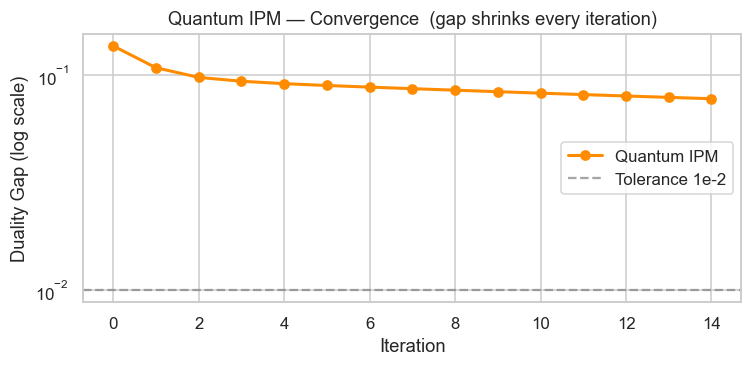

In [81]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(ipm_gaps, marker="o", color="darkorange", linewidth=2, label="Quantum IPM")
ax.axhline(1e-2, color="gray", linestyle="--", alpha=0.7, label="Tolerance 1e-2")
ax.set_xlabel("Iteration")
ax.set_ylabel("Duality Gap (log scale)")
ax.set_title("Quantum IPM — Convergence  (gap shrinks every iteration)")
ax.legend()
plt.tight_layout()
plt.show()


**Why doesn't the gap reach machine precision?**  Each Newton step is solved by HHL with `n_clk=4` clock qubits — the limited phase-estimation resolution adds noise to every Newton direction. The duality gap therefore *floors* at roughly the HHL noise level, even though the algorithm itself would converge polynomially in the noise-free limit. Bumping `n_clk` to 6 in the bonus exercise drops this floor visibly.

The figure below shows the HHL circuit from the **final** IPM Newton step.

Notice it has the **same four stages** as the plain HHL circuit in § 3 — just acting on a bigger KKT matrix (more system qubits → more controlled unitaries).


HHL circuit from final IPM Newton step:
  11 qubits | depth 27 | 34 gates


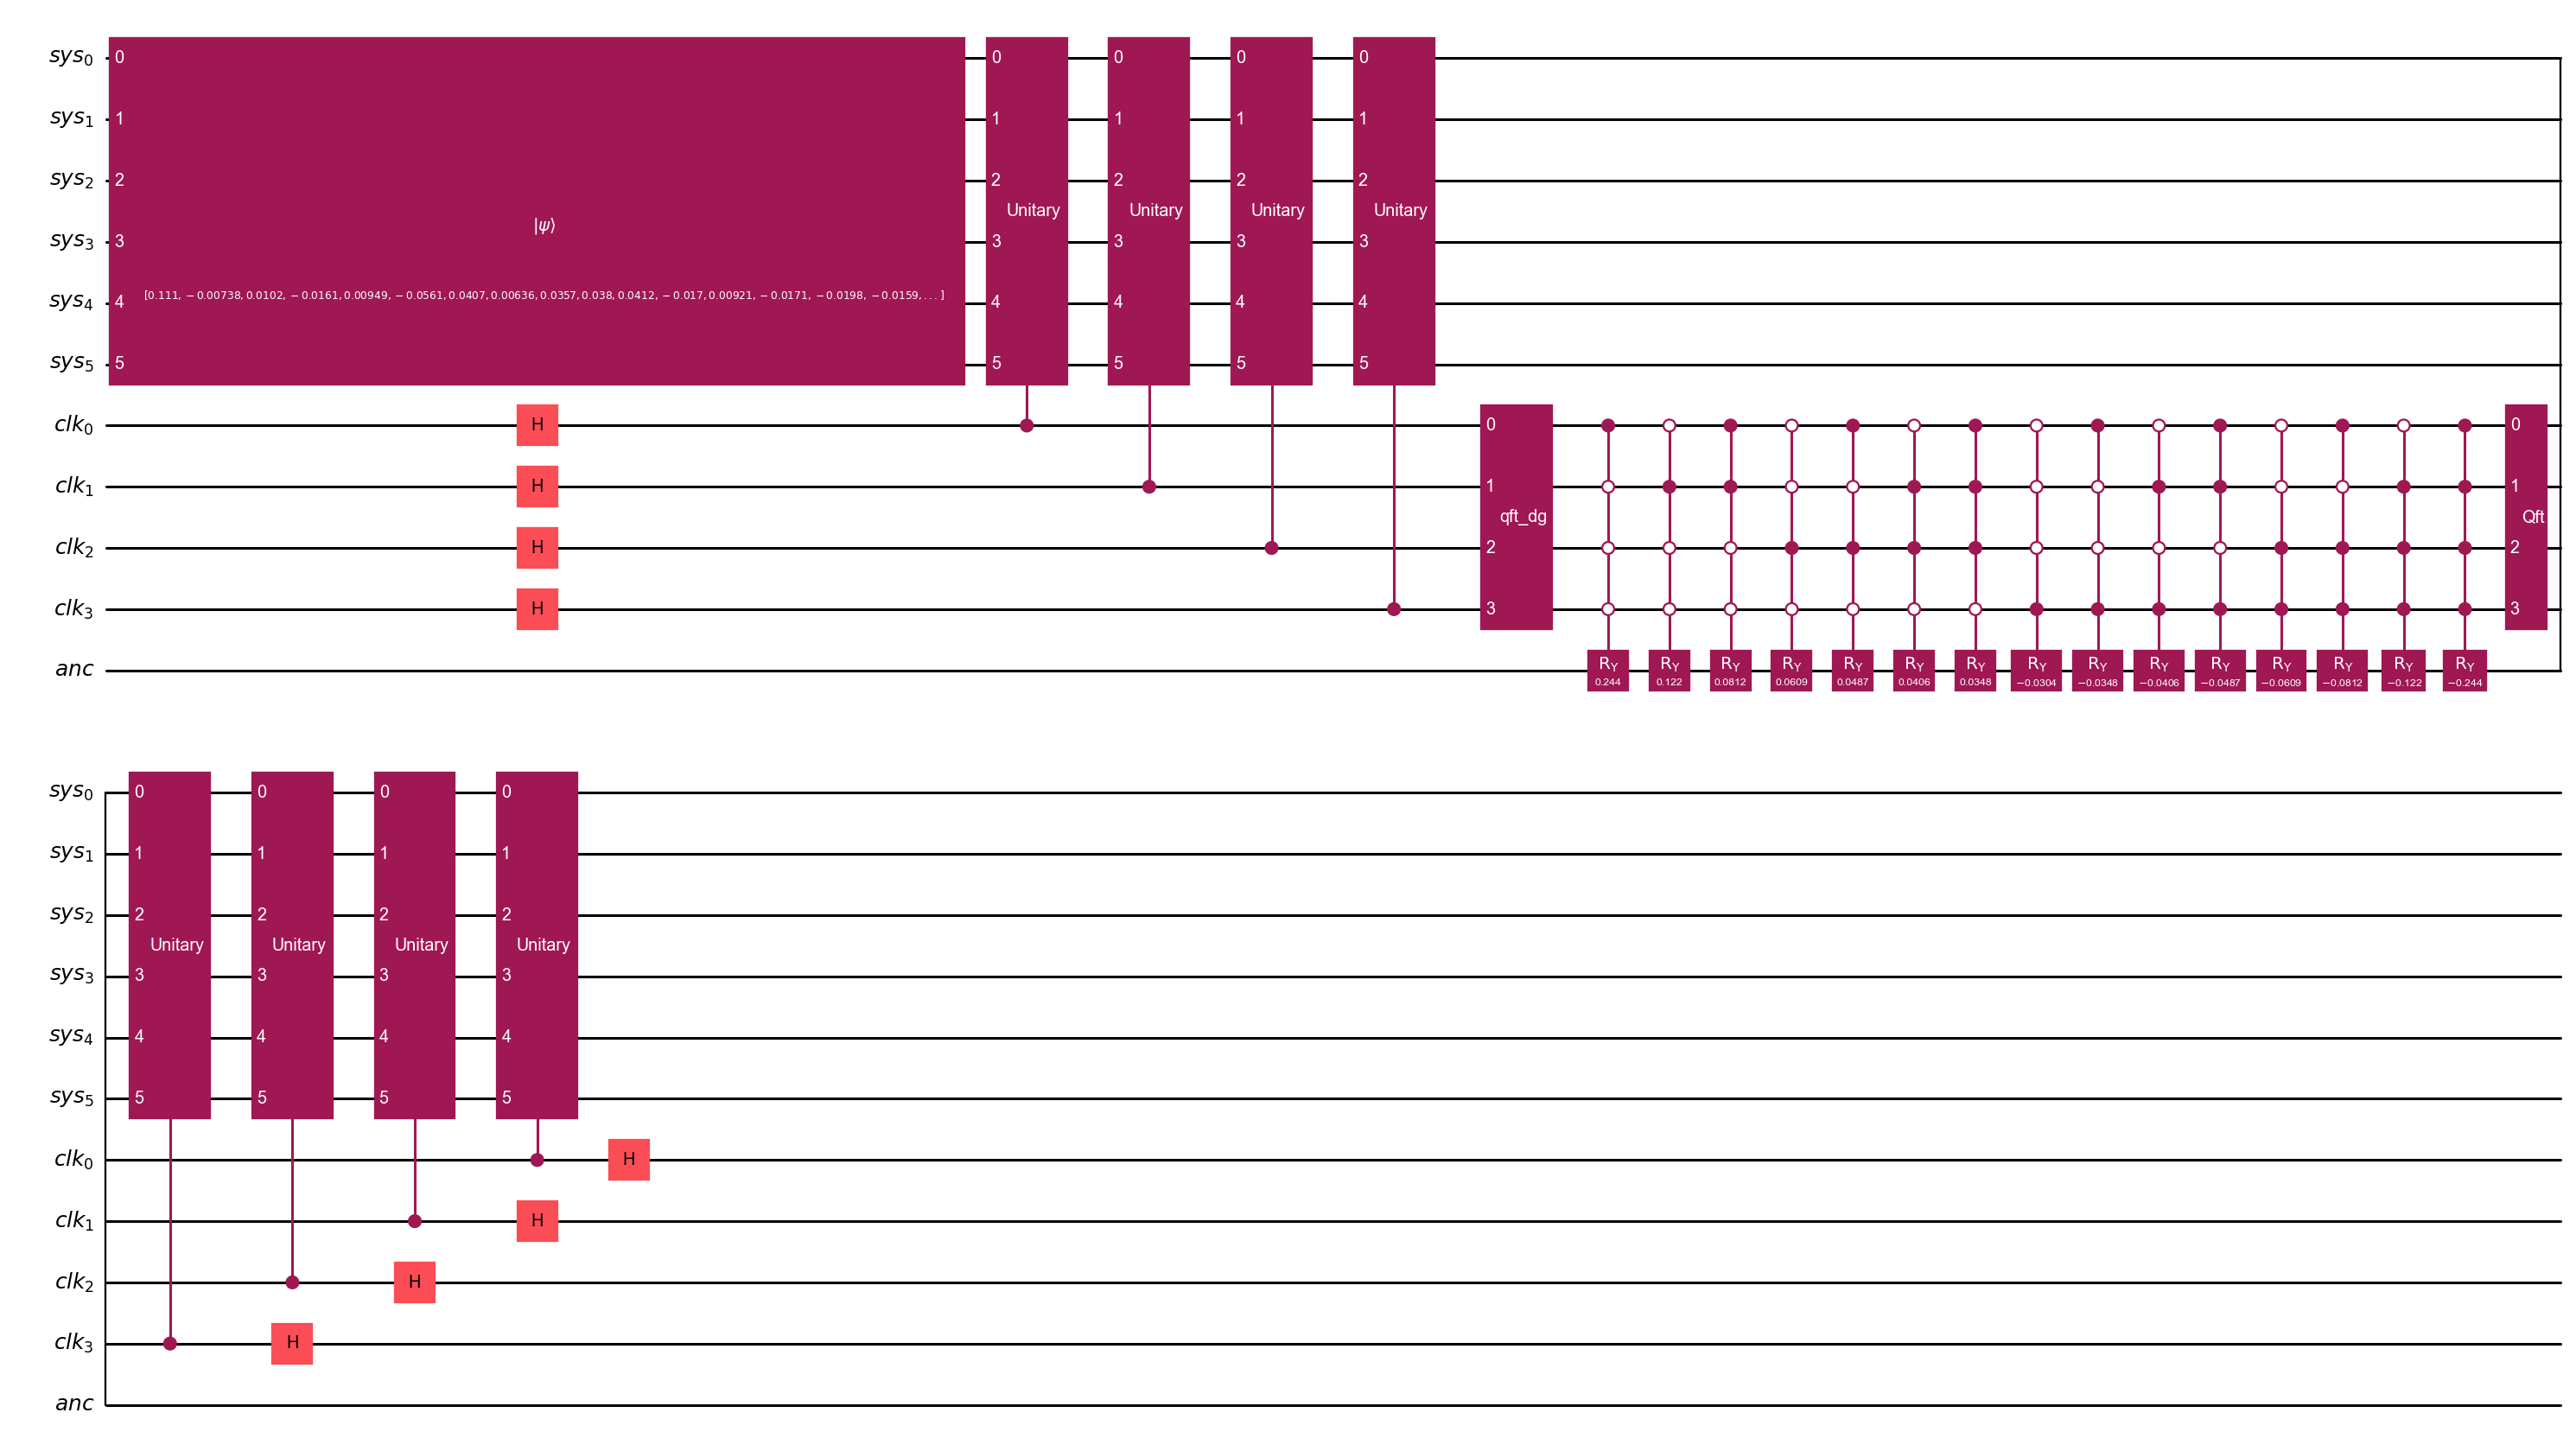

In [82]:
print(f"HHL circuit from final IPM Newton step:")
print(f"  {last_qc.num_qubits} qubits | depth {last_qc.depth()} | {last_qc.size()} gates")
last_qc.draw('mpl', style='iqp', fold=40)


## 7 · Three-Way Comparison

| Solver | Constraints enforced | Quantum component |
|--------|---------------------|-------------------|
| **Classical CVXPY** | All 4 (budget, long-only, cap, return) | None |
| **Plain HHL** | Budget + return only *(no inequalities)* | HHL — one direct solve |
| **Quantum IPM** | All 4 (full SOCP) | HHL — once per IPM iteration |

We expect:

- **Classical** and **Quantum IPM** to look similar — they solve the *same* constrained problem.
- **Plain HHL** to look different — it solved a *different* (more permissive) problem and ended up with shorts.


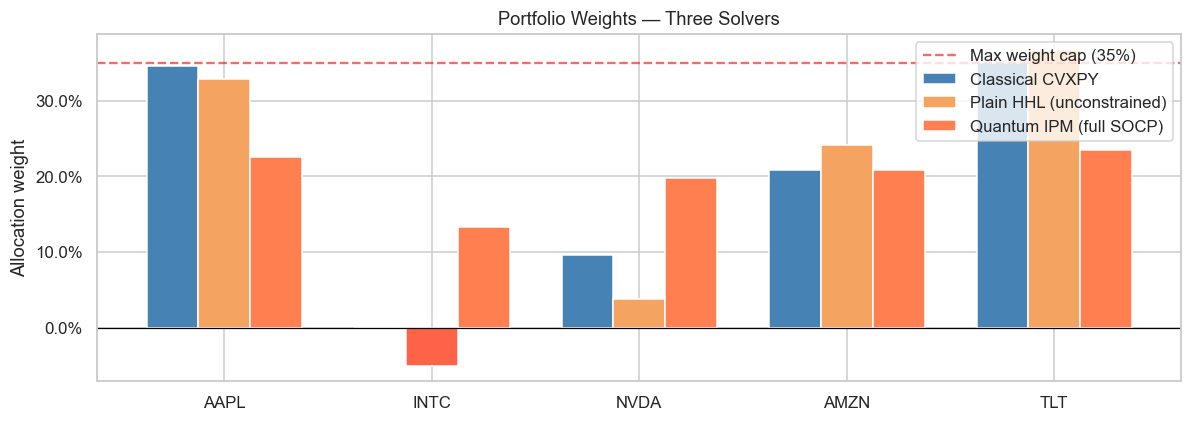

In [83]:
x_idx = np.arange(n)
width = 0.25

fig, ax = plt.subplots(figsize=(11, 4))

ax.bar(x_idx - width, w_cls if cls_ok else np.zeros(n),
       width, label="Classical CVXPY", color="steelblue")
ax.bar(x_idx,         w_hhl_raw,
       width, label="Plain HHL (unconstrained)",
       color=["tomato" if v < 0 else "sandybrown" for v in w_hhl_raw])
ax.bar(x_idx + width, w_qipm,
       width, label="Quantum IPM (full SOCP)", color="coral")

ax.axhline(CONFIG["max_weight"], color="red", linestyle="--", alpha=0.6,
           label=f"Max weight cap ({CONFIG['max_weight']:.0%})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_idx); ax.set_xticklabels(assets)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Allocation weight")
ax.set_title("Portfolio Weights — Three Solvers")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### In-sample metrics — what do they mean?

| Metric | Definition | Why we care |
|--------|------------|-------------|
| **Expected Return** | `µᵀw` — annualised | The portfolio's return if 2024-style markets persist |
| **Annual Variance** | `wᵀΣw` | Statistical risk — variance of portfolio return |
| **Annual Volatility** | `√(wᵀΣw)` | Standard deviation — typical one-year swing |
| **Min / Max weight** | smallest / largest position | Negative min = SHORT;  max should be ≤ cap |
| **Sum of weights** | `Σw` | Should be **1.0** (fully invested) |


In [84]:
def portfolio_metrics(w, mu, cov, label):
    return {
        "Solver":         label,
        "Exp. Return":    f"{float(w @ mu):.2%}",
        "Variance":       f"{float(w @ cov @ w):.4f}",
        "Volatility":     f"{float(np.sqrt(w @ cov @ w)):.2%}",
        "Min weight":     f"{float(np.min(w)):.2%}",
        "Max weight":     f"{float(np.max(w)):.2%}",
        "Sum of weights": f"{float(np.sum(w)):.4f}",
    }

rows = [
    portfolio_metrics(w_cls if cls_ok else np.zeros(n), mu_vec, cov_mat, "Classical CVXPY"),
    portfolio_metrics(w_hhl_raw,                        mu_vec, cov_mat, "Plain HHL"),
    portfolio_metrics(w_qipm,                           mu_vec, cov_mat, "Quantum IPM"),
]
display(pd.DataFrame(rows).set_index("Solver"))


,Exp. Return,Variance,Volatility,Min weight,Max weight,Sum of weights
Solver,,,,,,
Classical CVXPY,30.00%,0.0218,14.75%,0.00%,35.00%,1.0000
Plain HHL,27.46%,0.0167,12.91%,-5.00%,36.73%,0.9256
Quantum IPM,29.08%,0.0404,20.11%,13.32%,23.45%,1.0000


## 8 · Out-of-Sample Validation

We trained on 2024. Now we test on **2025** — data the solvers have never seen.
This is the moment of truth: in-sample fit ≠ real-world performance.

### OOS metrics — what do they mean?

| Metric | Definition | Why we care |
|--------|------------|-------------|
| **Total Return** | `Π(1 + r_t) − 1` over 2025 | Realised cumulative return on the held-out year |
| **Sharpe (ann.)** | `(annual return − rf) / annual volatility` | Risk-adjusted performance; **higher is better** |
| **HHI** | `Σ wᵢ²` (Herfindahl-Hirschman) | Concentration; **lower is better** (1/n = perfectly diversified, 1 = all in one asset) |


### 🧩 Task 3 — Choose the out-of-sample test period

We trained on 2024 data. Now we test the portfolios on a year the solvers have *never seen*. Set `test_start` and `test_end` to the full year **immediately following** the training window.

In [85]:
print("Downloading OOS data…")

# TODO: choose the out-of-sample test period (full calendar year after training)
test_start = "2025-01-01"
test_end   = "2025-12-31"

try:
    test_raw = yf.download(assets, start=test_start, end=test_end,
                            auto_adjust=True, progress=False)
    if isinstance(test_raw.columns, pd.MultiIndex):
        test_prices = test_raw["Close"][[a for a in assets if a in test_raw["Close"].columns]]
    else:
        test_prices = test_raw
    test_returns = test_prices.pct_change().dropna()
    oos_source   = f"yfinance {test_start} → {test_end} ({len(test_prices)} trading days)"
    print(f"✅  {oos_source}")
except Exception as e:
    print(f"⚠️  yfinance failed ({e}) — using synthetic OOS returns.")
    rng_oos      = np.random.default_rng(2025)
    oos_daily    = rng_oos.multivariate_normal(mu_vec / 252, cov_mat / 252, 252)
    test_returns = pd.DataFrame(oos_daily, columns=assets)
    oos_source   = "synthetic (seed=2025)"


✅  yfinance 2025-01-01 → 2025-12-31 (249 trading days)


<details>
<summary>💡 Hint</summary>

- Training window in `CONFIG`: `2024-01-01` → `2024-12-31`.
- The OOS year is the next full calendar year.
- yfinance expects ISO date strings: `"YYYY-MM-DD"`.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the task cell</summary>

```python
test_start = "2025-01-01"
test_end   = "2025-12-31"
```

*(Drop these two lines into the `...` slots in the cell above.)*

</details>

In [86]:
def oos_metrics(w, daily_returns, label):
    port       = (daily_returns @ w).values
    total_ret  = float((1 + port).prod() - 1)
    ann_factor = np.sqrt(252)
    sharpe     = float((port.mean() * 252) / (port.std() * ann_factor)) if port.std() > 0 else float("nan")
    hhi        = float(np.sum(w ** 2))
    return {
        "Solver":                label,
        "OOS Total Return":      f"{total_ret:.2%}",
        "Sharpe (annualised)":   f"{sharpe:.3f}",
        "HHI (concentration)":   f"{hhi:.4f}",
    }

metrics_oos = [
    oos_metrics(w_cls if cls_ok else np.zeros(n), test_returns, "Classical CVXPY"),
    oos_metrics(w_hhl_raw,                        test_returns, "Plain HHL"),
    oos_metrics(w_qipm,                           test_returns, "Quantum IPM"),
]
print(f"\nOOS source: {oos_source}")
display(pd.DataFrame(metrics_oos).set_index("Solver"))



OOS source: yfinance 2025-01-01 → 2025-12-31 (249 trading days)


,OOS Total Return,Sharpe (annualised),HHI (concentration)
Solver,,,
Classical CVXPY,12.98%,0.719,0.2944
Plain HHL,6.48%,0.448,0.3055
Quantum IPM,26.59%,1.081,0.2064


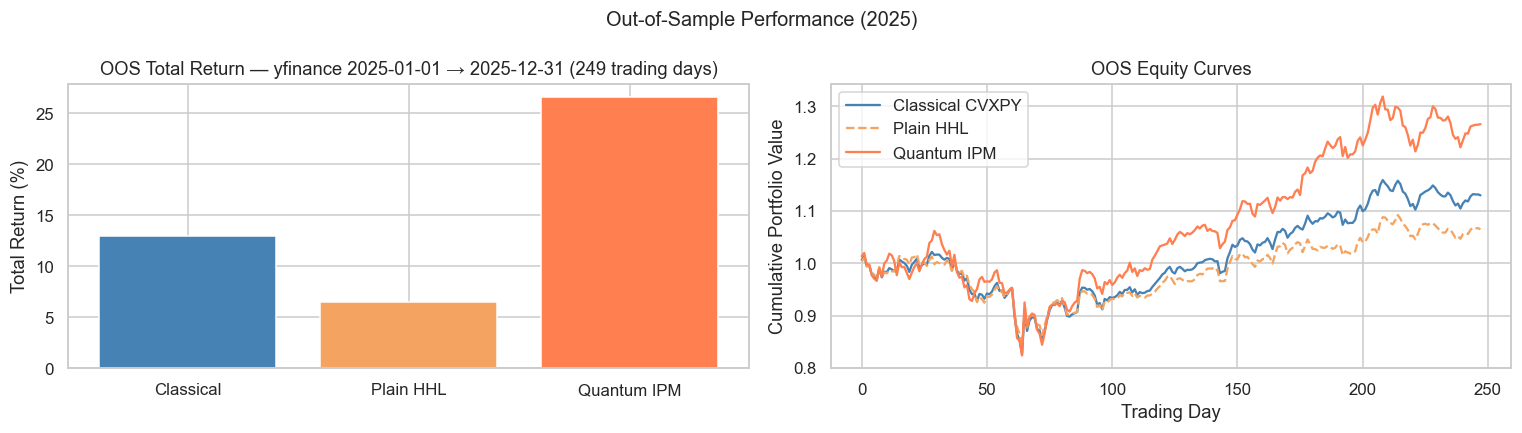

In [87]:
w_cls_plot = w_cls if cls_ok else np.zeros(n)
cls_curve  = (1 + test_returns @ w_cls_plot).cumprod()
hhl_curve  = (1 + test_returns @ w_hhl_raw).cumprod()
qipm_curve = (1 + test_returns @ w_qipm).cumprod()

oos_totals = [(1 + test_returns @ w).prod() - 1
              for w in [w_cls_plot, w_hhl_raw, w_qipm]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(["Classical", "Plain HHL", "Quantum IPM"],
            [v * 100 for v in oos_totals],
            color=["steelblue", "sandybrown", "coral"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Total Return (%)")
axes[0].set_title(f"OOS Total Return — {oos_source}")

axes[1].plot(cls_curve.values,  color="steelblue",   label="Classical CVXPY")
axes[1].plot(hhl_curve.values,  color="sandybrown",  label="Plain HHL", linestyle="--")
axes[1].plot(qipm_curve.values, color="coral",       label="Quantum IPM")
axes[1].set_xlabel("Trading Day")
axes[1].set_ylabel("Cumulative Portfolio Value")
axes[1].set_title("OOS Equity Curves")
axes[1].legend()

plt.suptitle("Out-of-Sample Performance (2025)", fontsize=13)
plt.tight_layout()
plt.show()


#### Quantum Advantage!

Well... Not necessarily for 2026...
But now we know how to incorporate constraints into the continuous optimization problem! 🙂

**Reading the OOS chart:**

- The **Classical CVXPY** and **Quantum IPM** curves should track each other closely — both enforced the same constraints and converged to nearly the same portfolio. Any gap reflects quantisation noise in HHL (controlled by `n_clk`).
- The **Plain HHL** curve can drift very differently — it's holding *short* positions, so it makes (or loses) money when the shorted assets fall (or rise) in 2025. Its risk profile is entirely different.


## 9 · Discussion & Extensions

### Recap of the story

1. **Plain HHL** can solve `Ax = b`, but cannot enforce inequalities. Applied directly to the unconstrained KKT system, the underlying math wants to **short low-return assets** (clearly visible in the analytical solve) — and even the equality constraints aren't enforced exactly because HHL is approximate.
2. The paper's idea: reformulate as an **SOCP** and run a classical **IPM skeleton**, replacing each Newton-step linear solve with **HHL**.
3. Both the classical CVXPY solver and the Quantum IPM converge to (nearly) the same constrained optimum — same constraints, same answer.

### Is there a quantum advantage *right now*?

**In this simulation — no.** We simulate HHL classically, which is *slower* than Cholesky.
The theoretical speedup **O(n · κ · √r · log n)** vs **O(n³ · √r)** requires:

1. A fault-tolerant quantum computer with thousands of logical qubits.
2. A large portfolio (**n ≫ 1 000**) where the log n factor dominates.
3. A well-conditioned covariance matrix (bounded κ).

### 🎓 Further Exploration

1. **Higher HHL precision** — Set `CONFIG['quantum_hhl_n_clk'] = 6` and rerun §3 + §6.
   The duality-gap floor should drop and QIPM weights should track CVXPY more closely.
   Trade-off: circuit depth roughly doubles.

2. **Tighter cap** — Set `CONFIG['max_weight'] = 0.25`. Both solvers are forced toward a
   flatter allocation. Does the QIPM still match CVXPY weight-for-weight?

3. **Larger universe** — Add `"GOOGL"` to `CONFIG['tickers']`. The KKT system grows to
   8×8 (now exactly power-of-two — no padding needed). How much does runtime change?

### Further reading

- Kerenidis, Prakash & Szilágyi (2019) — *Quantum Algorithms for Portfolio Optimization*
- Harrow, Hassidim & Lloyd (2009) — *Quantum Algorithm for Linear Systems of Equations*
- Boyd & Vandenberghe — *Convex Optimization* (free PDF) — Chapters 4 & 11


---

## About

* This tutorial was developed by **Nadav Ben-Ami** as a workshop in the course "Application of Quantum Computing", Ludwig Maximilian University of Munich (LMU)
* The Course is given by  PD Dr. habil. Jeanette Miriam Lorenz. Head of Quantum Computing department at the Fraunhofer Institute for Cognitive Systems, and senior lecturer at LMU

[![GitHub](https://img.shields.io/badge/GitHub-Nadav138-181717?logo=github)](https://github.com/Nadav138) &nbsp;
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Nadav_Ben--Ami-0077B5?logo=linkedin)](https://linkedin.com/in/nba13/)

*Based on the full research implementation in [`quantum_ipm_research.ipynb`](../research/quantum_ipm_research.ipynb) in this repository.*
